# Computer Vision with PyTorch

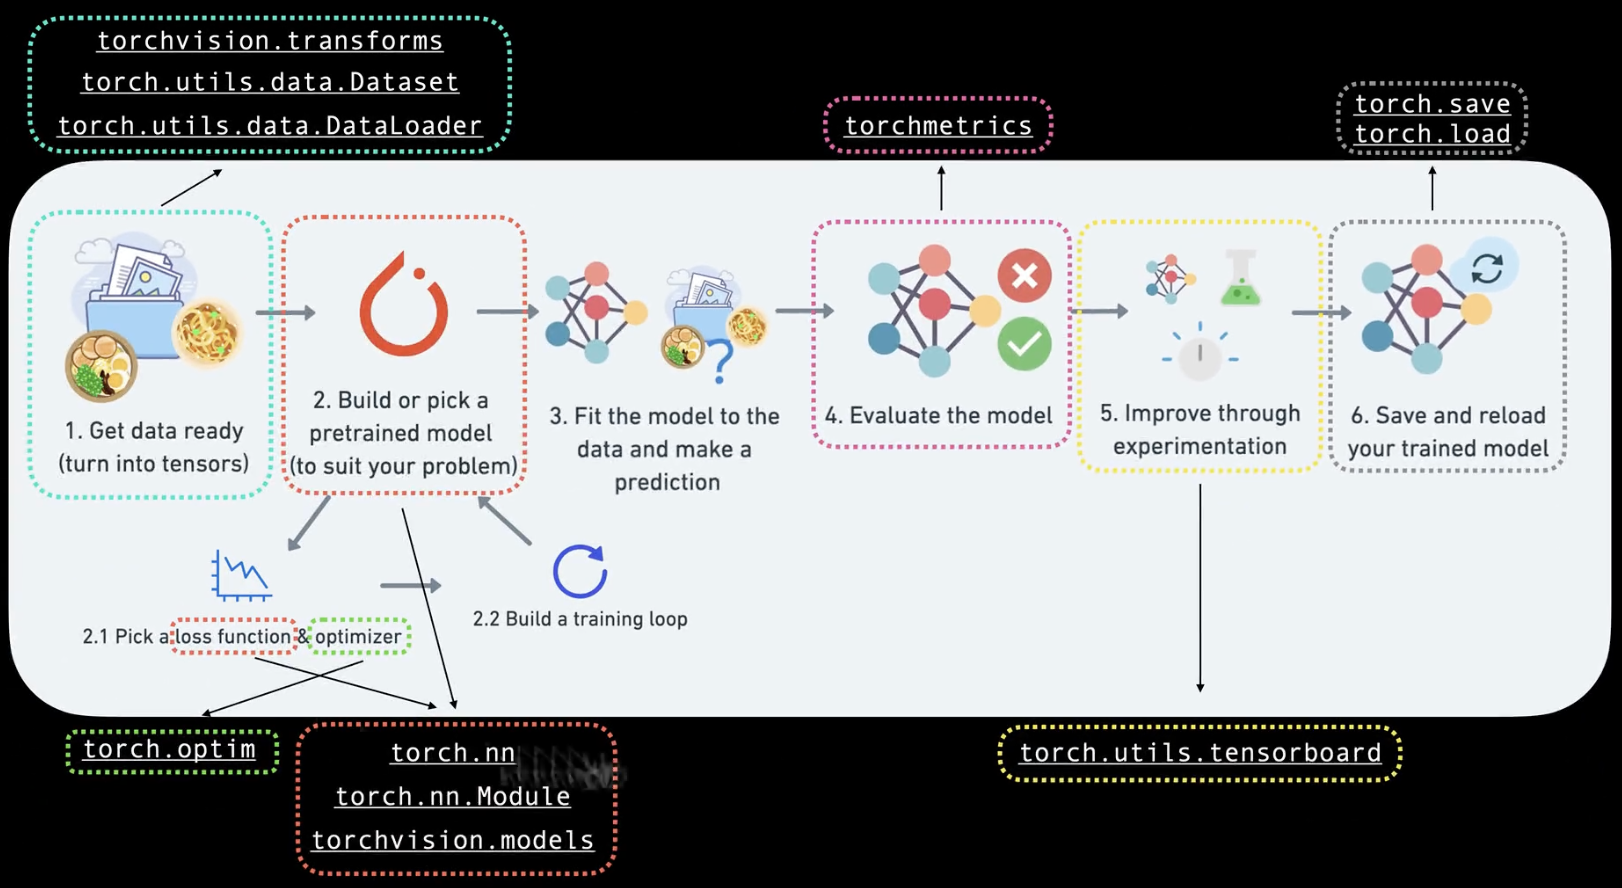

Now an intersting thing we will see: our GPU using MPS is still slow: 

https://horace.io/brrr_intro.html

* [`torchvision`](https://docs.pytorch.org/vision/stable/index.html): based libary for PyTorch vision problem
* [`torchivision.datasets`](https://docs.pytorch.org/vision/0.8/datasets.html): get the datasets and data loading functions for computer visions
* [`torchvision.models`](https://docs.pytorch.org/vision/0.9/models.html): get pretrained vision models that we can leverage for our own problems
* [`torchvision.transforms`](https://docs.pytorch.org/vision/0.8/transforms.html): Functions for manipulating our vision data (images)
* [`torch.utils.data.Dataset`](https://docs.pytorch.org/vision/main/datasets.html): Base dataset class for PyTorch
* [`torch.utils.data.DataLoader`](https://docs.pytorch.org/vision/main/datasets.html): Creates a Python iterable over a dataset

## 1. Import packages

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
#import torchinfo
#import torchmetrics

In [7]:
from torchinfo import summary

In [3]:
import torch.optim as opt

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

In [5]:
print(f"{torch.__version__}")
print(f"{torchvision.__version__}")

2.12.0
0.27.0


In [6]:
device = "mps" if torch.backends.mps.is_available() else "cpus"
print(f"We are going to use: {device.upper()}")

We are going to use: MPS


In [28]:
torch.backends.mps.is_built()

True

## 2. Get the data

We are going to use the [`Fashion MNIST`](https://fr.wikipedia.org/wiki/Fashion_MNIST) dataset in this Notebook.

We are going to use it directly from `torch.datasets`

In [32]:
train_data = datasets.FashionMNIST(root="data", # where to download to
                                   train=True, # do we want the train dataset
                                   download=True, # do we want to donload the images
                                   transform=ToTensor(),  # do we want to transform the images
                                   target_transform=None) # how do we watn to tranform the labels

In [33]:
test_data  = datasets.FashionMNIST(root="data", 
                                   train = False, 
                                   download=True, 
                                   transform=ToTensor(), 
                                   target_transform=None)

At this point, the `torchvision.datasets`already transformed the data into `datasets`for us

In [34]:
len(train_data), len(test_data)

(60000, 10000)

In [35]:
# Visualize the data
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [36]:
image, target = train_data[0]
image, target, image.shape

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [37]:
classe_names = train_data.classes
classe_names[target]

'Ankle boot'

In [38]:
test_image = image

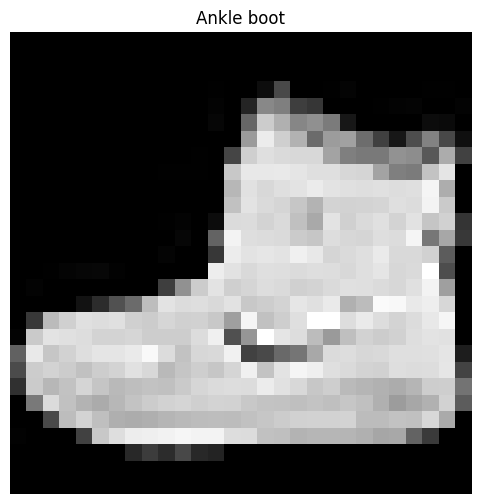

In [39]:
plt.figure(figsize=(10,6))
plt.title(f"{classe_names[target]}")
plt.imshow(test_image.squeeze(), cmap="gray") # remove the extra dimensions for color channels
plt.axis(False)
plt.show()

## 3. Preparing the data for our model (`DataLoader`)

Right now we have our data in the form of a PyTorch Dataset (curtosy of the Fashion MNIST)

We need to transform this dataset into a DataLoader (in order to iterate over it efficiently) and also give the opportunity to the model to learn and adapt several times within an epoch

So we will turn it into **batches** (we can send the whole data to the GPU but it is more efficient to work in baches)

see:

* [Mini-batch gradient descent](http://cs230.stanford.edu/files/old_slides/C2M2.pdf) (slides)
* [Mini-batch gradient descent](https://www.youtube.com/watch?v=4qJaSmvhxi8) (video)

In [40]:
SEED = 42
BATCH_SIZE = 32

In [41]:
torch.manual_seed(SEED)

In [42]:
from torch.utils.data import DataLoader

In [43]:
train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=BATCH_SIZE,
                              shuffle=True, # shuffle is importante because we want as much as possible of each class into each batch               
                              )

test_dataloader = DataLoader(dataset=test_data, 
                              batch_size=BATCH_SIZE,
                              shuffle=False, # shuffle is importante because we want as much as possible of each class into each batch
                              )

In [44]:
images, labels = next(iter(train_dataloader)) # transfrome the loader into an iterable and take the next batch using next

In [45]:
images[0].shape, labels.shape

(torch.Size([1, 28, 28]), torch.Size([32]))

## Model 0: First CNN

In [89]:
class FirstComputerVision(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3)), # out_channel: dimensions of the output of the convolution layer: depends on the number of filters: e.g., input = (1,28,28) with 32 filters and no padding: (26,26,32)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2)),
            nn.Flatten(),
            nn.LazyLinear(out_features=10) # lazyLinear prevents guessing the in_channel
        )

    def forward(self, inputs):
        return self.network(inputs)

In [95]:
model_cnn_0 = FirstComputerVision()

In [100]:
image.shape

torch.Size([1, 28, 28])

In [106]:
data_dummy = torch.randn(size=(1,1,28,28)).to(device)
model_cnn_dummy = FirstComputerVision().to(device)
_ = model_cnn_dummy(data_dummy)

In [107]:
summary(model=model_cnn_dummy, input_size=(1,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
FirstComputerVision                      [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 32, 26, 26]           320
│    └─ReLU: 2-2                         [1, 32, 26, 26]           --
│    └─MaxPool2d: 2-3                    [1, 32, 13, 13]           --
│    └─Conv2d: 2-4                       [1, 64, 11, 11]           18,496
│    └─ReLU: 2-5                         [1, 64, 11, 11]           --
│    └─MaxPool2d: 2-6                    [1, 64, 5, 5]             --
│    └─Flatten: 2-7                      [1, 1600]                 --
│    └─Linear: 2-8                       [1, 10]                   16,010
Total params: 34,826
Trainable params: 34,826
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.47
Input size (MB): 0.00
Forward/backward pass size (MB): 0.24
Params size (MB): 0.14
Estimated Total Size (M

In [97]:
optimizer = opt.Adam(lr=0.001, params=model_cnn_0.parameters()) # associate the parameters of the model to the optimizer so it knows what is affected by backprogagation
criterion = nn.CrossEntropyLoss()

In [98]:
# put everything to the proper device
model_cnn_0 = model_cnn_0.to(device)

In [99]:
epochs = 250
losses_train = []
losses_test = []
for epoch in range(epochs):
    # set the model to training moode
    model_cnn_0.train()
    # loop over the batches:
    total_loss_train = 0 # ohterwise the loss increases between each epoch
    for images, labels in train_dataloader:
        X_batch_train, y_batch_train = images.to(device), labels.to(device)
        # make a prediction (foward pass)
        preds_train = model_cnn_0(X_batch_train)
        # compute the loss
        loss_train = criterion(preds_train, y_batch_train)
        # reset the gradient
        optimizer.zero_grad()
        # evaluate the gradients (backpropagation)
        loss_train.backward()
        # update the optimizer, i.e., perform gd to updates the weights
        optimizer.step()
        total_loss_train += loss_train.item()
    losses_train.append(total_loss_train)

    # Evaluation loop
    model_cnn_0.eval()
    total_loss_test = 0
    with torch.inference_mode():
        for images_test, label_test in test_dataloader:
            X_test_batch, y_test_batch = images_test.to(device), label_test.to(device)
            preds_test = model_cnn_0(X_test_batch) # prediction on the test batch
            loss_test = criterion(preds_test, y_test_batch)
            total_loss_test += loss_test.item()
    losses_test.append(total_loss_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss Train: {losses_train[epoch]} | Loss Test: {losses_test[epoch]}")

Epoch: 0 | Loss Train: 914.8016770258546 | Loss Test: 121.21923910826445
Epoch: 10 | Loss Train: 321.99336388893425 | Loss Test: 84.21942867338657
Epoch: 20 | Loss Train: 217.1507912715897 | Loss Test: 101.8928290605545
Epoch: 30 | Loss Train: 153.44141000835225 | Loss Test: 130.86849117837846
Epoch: 40 | Loss Train: 117.73492335798801 | Loss Test: 161.69336107373238
Epoch: 50 | Loss Train: 93.70348537560494 | Loss Test: 189.88694821065292
Epoch: 60 | Loss Train: 69.9422374264177 | Loss Test: 221.63952741073444
Epoch: 70 | Loss Train: 58.31449064771732 | Loss Test: 242.1363505451809


KeyboardInterrupt: 

## Model 1: TinyVGG (From CNN explainer Website)

This section helps introduces the notion of working in `block` when building a neural network

In [ ]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Feature extractors
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, kernel_size=3, 
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1, 
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        # Classifier layer
        self.output = nn.Sequential(
            nn.Flatten(), # do not forget to flatten the previous layer
            nn.LazyLinear(out_features=output_shape)) # Avoid having to compute the in_feature
    
    def forward(self, inputs:torch.Tensor) -> torch.Tensor:
        x = self.conv_block_1(inputs)
        print(x.shape)
        x = self.conv_block_2(x)
        print(x.shape)
        x = self.output(x)
        return x

In [68]:
torch.manual_seed(42)

In [70]:
vgg_model = TinyVGG(input_shape=1, hidden_units=10, output_shape=10).to(device)

In [71]:
summary(vgg_model)

Layer (type:depth-idx)                   Param #
TinyVGG                                  --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       100
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       910
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-6                       910
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       910
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
├─Sequential: 1-3                        --
│    └─Flatten: 2-11                     --
│    └─LazyLinear: 2-12                  --
Total params: 2,830
Trainable params: 2,830
Non-trainable params: 0

### Trick to evaluate the dimensions

Print the shape when passing the dat through the network

## Model 2: LeNet-5 (Yann LeCun) replication